# 02 - OOD Model Generalization Evaluation & Benchmark

This notebook executes the out-of-distribution (OOD) generalization testing campaign for the WiFi CSI presence detection system.
The objective is to evaluate pre-trained models on unseen physical environments and inter-node distances (other than the baseline 2.0-meter configuration).

### Validation Principles:
- **Zero Retraining Policy**: Models are evaluated strictly as pre-trained inference artifacts.
- **Full-Feature vs Lightweight Comparison**: Compares the 4 full-feature models (648 features) against their 4 corresponding lightweight variants (20 features across 5 optimal subcarriers).
- **Subcarrier Alignment**: Feature extraction strictly uses the reference 162-subcarrier mapping (`data/03_processed/valid_subcarrier_mapping.csv`).
- **Publication-Ready Figures & Reports**: All metrics and figures are exported to `outputs/generalization/`.


## 1. Environment Setup & Package Imports

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

# Locate repository root
_p = Path.cwd()
for PROJECT_ROOT in [_p, *_p.parents]:
    if (PROJECT_ROOT / "requirements.txt").exists():
        break

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Established wifi_csi package imports
from wifi_csi.parsing.metadata_parser import discover_sessions, load_metadata
from wifi_csi.signal.amplitudes import load_session_arrays
from wifi_csi.features.extractor import build_feature_dataset
from wifi_csi.evaluation.metrics import compute_metrics, false_alarm_rate
from wifi_csi.evaluation.plotting import plot_confusion_matrix, plot_model_comparison

# Target directories
DATA_DIR = PROJECT_ROOT / "data" / "01_raw" / "generalization"
MODELS_DIR = PROJECT_ROOT / "models" / "registry"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "generalization"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MAPPING_FILE = PROJECT_ROOT / "data" / "03_processed" / "valid_subcarrier_mapping.csv"

# Plotting configuration
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.3
})

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Data source: {DATA_DIR.resolve()}")
print(f"Outputs target: {OUTPUTS_DIR.resolve()}")
print(f"Model registry: {MODELS_DIR.resolve()}")


Project root: /home/xavier/dev/wifi-csi-presence-detection
Data source: /home/xavier/dev/wifi-csi-presence-detection/data/01_raw/generalization
Outputs target: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization
Model registry: /home/xavier/dev/wifi-csi-presence-detection/models/registry


## 2. Session Discovery and Signal Loading

Scan `data/01_raw/generalization/` for valid sessions, parse metadata, and load raw CSI arrays.

In [2]:
discovered_df = discover_sessions(DATA_DIR, required_status="VALID")
print(f"Discovered {len(discovered_df)} valid session(s) in {DATA_DIR.name}:")
display(discovered_df[["session_id", "label_name", "metadata_status", "file_size_mb", "csv_filename"]])

loaded_sessions = []
session_metadata_records = []

for rec in discovered_df.to_dict("records"):
    if rec["metadata_status"] != "VALID":
        warnings.warn(f"Skipping session {rec['session_id']} due to invalid metadata status: {rec['metadata_status']}")
        continue
    session = load_session_arrays(rec["csv_path"], rec["metadata_path"])
    loaded_sessions.append(session)
    
    meta = session["metadata"]
    env_info = meta.get("environment", {})
    setup_info = meta.get("setup", {})
    nodes_info = setup_info.get("nodes", {})
    
    session_metadata_records.append({
        "session_id": session["session_id"],
        "label_name": session["label_name"],
        "label": session["label"],
        "environment_id": env_info.get("environment_id", "unknown"),
        "tx_rx_los_distance_m": nodes_info.get("tx_rx_los_distance_m", env_info.get("tx_rx_distance_m")),
        "valid_rows": session["metrics"]["valid_rows"],
        "effective_rate_hz": round(session["effective_rate_hz"], 2),
        "duration_s": round(session["metrics"]["duration_s"], 1),
        "active_interval": f"{session['active_start']} -> {session['active_end']}",
        "scenario_notes": env_info.get("scenario_notes", "")
    })

session_summary_df = pd.DataFrame(session_metadata_records)
display(session_summary_df)


Discovered 9 valid session(s) in generalization:


,session_id,label_name,metadata_status,file_size_mb,csv_filename
0,GA,empty,VALID,5.003160,session_GA_empty_20260925_2236.csv
1,GB,occupied_still,VALID,4.580058,session_GB_occupied_still_20260925_2240.csv
2,GC,empty,VALID,5.074747,session_GC_empty_20260925_2254.csv
3,GD,occupied_still,VALID,4.335147,session_GD_occupied_still_20260925_2258.csv
4,GE,empty,VALID,5.247404,session_GE_empty_20260925_2305.csv
5,GF,occupied_still,VALID,5.157393,session_GF_occupied_still_20260925_2322.csv
6,GG,empty,INVALID,5.259027,session_GG_empty_20260925_2332.csv
7,GH,empty,VALID,5.278940,session_GH_empty_20260925_2336.csv
8,GI,occupied_still,VALID,4.559486,session_GI_occupied_still_20260925_2342.csv


/tmp/ipykernel_227412/475768375.py:10: UserWarning: Skipping session GG due to invalid metadata status: INVALID
  warnings.warn(f"Skipping session {rec['session_id']} due to invalid metadata status: {rec['metadata_status']}")


,session_id,label_name,label,environment_id,tx_rx_los_distance_m,valid_rows,effective_rate_hz,duration_s,active_interval,scenario_notes
0,GA,empty,0,outdoor_area_3m_los,3.0,4170,27.80,149.9,2026-09-25 22:37:42 -> 2026-09-25 22:38:42,Direct Line-of-Sight (LOS) test at 3.0m distan...
1,GB,occupied_still,1,outdoor_area_3m_los,3.0,4053,27.02,150.0,2026-09-25 22:43:39 -> 2026-09-25 22:44:39,Direct Line-of-Sight (LOS) test at 3.0m distan...
2,GC,empty,0,outdoor_area_4m_los,4.0,4393,29.28,150.0,2026-09-25 22:55:51 -> 2026-09-25 22:56:51,Direct Line-of-Sight (LOS) test at 4.0m distan...
3,GD,occupied_still,1,outdoor_area_4m_los,4.0,4104,27.36,150.0,2026-09-25 23:00:21 -> 2026-09-25 23:01:21,Direct Line-of-Sight (LOS) test at 4.0m distan...
4,GE,empty,0,outdoor_area_5m_los,5.0,4353,29.02,150.0,2026-09-25 23:06:29 -> 2026-09-25 23:07:29,Direct Line-of-Sight (LOS) test at 5.0m distan...
5,GF,occupied_still,1,outdoor_area_5m_los,5.0,4384,29.23,150.0,2026-09-25 23:24:39 -> 2026-09-25 23:25:39,Direct Line-of-Sight (LOS) test at 5.0m distan...
6,GH,empty,0,outdoor_area_2m_los,2.0,4365,29.10,150.0,2026-09-25 23:38:16 -> 2026-09-25 23:39:16,Direct Line-of-Sight (LOS) test at 2.0m distan...
7,GI,occupied_still,1,outdoor_area_2m_los,2.0,4012,26.75,149.9,2026-09-25 23:43:43 -> 2026-09-25 23:44:43,Direct Line-of-Sight (LOS) test at 2.0m distan...


## 3. Subcarrier Alignment & Feature Extraction Pipeline

Extract features using the reference 162-subcarrier mapping (`valid_subcarrier_mapping.csv`).
This guarantees that `sc000` through `sc161` correspond identically to the exact physical subcarrier frequencies that the pre-trained pipelines were trained on.

In [3]:
# Load the 162-subcarrier mapping used in training to guarantee exact feature alignment
mapping_df = pd.read_csv(MAPPING_FILE)
raw_indices = mapping_df["raw_subcarrier_index"].values
n_raw_subcarriers = loaded_sessions[0]["amplitude_matrix"].shape[1]

reference_mask = np.zeros(n_raw_subcarriers, dtype=bool)
reference_mask[raw_indices] = True
print(f"Reference mask initialized: {int(reference_mask.sum())} subcarriers matching training registry.")

# Build standard feature dataset (2.0s non-overlapping windows)
features_df, out_mapping_df, processing_details = build_feature_dataset(
    loaded_sessions,
    shared_mask=reference_mask,
    window_seconds=2.0
)

# Merge session-level metadata into windowed dataset
meta_lookup = session_summary_df.set_index("session_id")[["environment_id", "tx_rx_los_distance_m", "scenario_notes"]].to_dict("index")
features_df["environment_id"] = features_df["session_id"].map(lambda sid: meta_lookup.get(sid, {}).get("environment_id", "unknown"))
features_df["tx_rx_los_distance_m"] = features_df["session_id"].map(lambda sid: meta_lookup.get(sid, {}).get("tx_rx_los_distance_m", np.nan))
features_df["scenario_notes"] = features_df["session_id"].map(lambda sid: meta_lookup.get(sid, {}).get("scenario_notes", ""))

y_true = features_df["label"].to_numpy(dtype=int)
print(f"\nFeature dataset built successfully:")
print(f"  Total window samples: {len(features_df)}")
print(f"  Total columns: {features_df.shape[1]}")
print(f"  Class balance: {dict(pd.Series(y_true).value_counts())} (0=empty, 1=occupied)")
print(f"  Tested environments: {list(features_df['environment_id'].unique())}")
print(f"  Tested distances (m): {sorted(list(features_df['tx_rx_los_distance_m'].unique()))}")


Reference mask initialized: 162 subcarriers matching training registry.

Feature dataset built successfully:
  Total window samples: 232
  Total columns: 660
  Class balance: {0: np.int64(116), 1: np.int64(116)} (0=empty, 1=occupied)
  Tested environments: ['outdoor_area_3m_los', 'outdoor_area_4m_los', 'outdoor_area_5m_los', 'outdoor_area_2m_los']
  Tested distances (m): [np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


## 4. Pre-Trained Model Registry Loading & Verification

Load the 8 pre-trained model bundles from `models/registry/`:
- 4 Full Feature Models (648 features across all 162 subcarriers)
- 4 Lightweight Models (20 features across top 5 optimal subcarriers: `sc041, sc040, sc042, sc047, sc012`)

In [4]:
MODEL_SPECS = [
    # Full feature models (648 features)
    {"name": "gradient_boosting", "bundle": "gradient_boosting_bundle", "family": "Gradient Boosting", "type": "Full", "features": 648},
    {"name": "random_forest", "bundle": "random_forest_bundle", "family": "Random Forest", "type": "Full", "features": 648},
    {"name": "svm", "bundle": "svm_bundle", "family": "SVM", "type": "Full", "features": 648},
    {"name": "mlp", "bundle": "mlp_bundle", "family": "MLP", "type": "Full", "features": 648},
    # Lightweight models (20 features)
    {"name": "gradient_boosting_light", "bundle": "gradient_boosting_light_bundle", "family": "Gradient Boosting", "type": "Lightweight", "features": 20},
    {"name": "random_forest_light", "bundle": "random_forest_light_bundle", "family": "Random Forest", "type": "Lightweight", "features": 20},
    {"name": "svm_light", "bundle": "svm_light_bundle", "family": "SVM", "type": "Lightweight", "features": 20},
    {"name": "mlp_light", "bundle": "mlp_light_bundle", "family": "MLP", "type": "Lightweight", "features": 20},
]

loaded_models = {}
for spec in MODEL_SPECS:
    bundle_path = MODELS_DIR / spec["bundle"]
    pipeline = joblib.load(bundle_path / "pipeline.joblib")
    card_path = bundle_path / "model_card.json"
    card = json.loads(card_path.read_text()) if card_path.exists() else {}
    
    loaded_models[spec["name"]] = {
        "pipeline": pipeline,
        "card": card,
        "spec": spec,
        "expected_features": list(pipeline.feature_names_in_)
    }
    print(f"Loaded: {spec['name']:25s} | Type: {spec['type']:11s} | In-features: {len(pipeline.feature_names_in_)}")


Loaded: gradient_boosting         | Type: Full        | In-features: 648
Loaded: random_forest             | Type: Full        | In-features: 648
Loaded: svm                       | Type: Full        | In-features: 648
Loaded: mlp                       | Type: Full        | In-features: 648
Loaded: gradient_boosting_light   | Type: Lightweight | In-features: 20
Loaded: random_forest_light       | Type: Lightweight | In-features: 20
Loaded: svm_light                 | Type: Lightweight | In-features: 20
Loaded: mlp_light                 | Type: Lightweight | In-features: 20


## 5. Model Inference & Comprehensive Metric Evaluation

Run inference on the OOD feature dataset and compute all evaluation metrics:
- **Accuracy**
- **Macro F1-Score**
- **Weighted F1-Score**
- **Sensitivity (TPR / Recall)**
- **Specificity (TNR)**
- **False Alarm Rate (FPR)**
- **Confusion Matrix Counts (TP, TN, FP, FN)**
- **In-Distribution vs Out-of-Distribution F1 Degradation**

In [5]:
results_list = []
predictions_dict = {}

for name, model_data in loaded_models.items():
    pipe = model_data["pipeline"]
    spec = model_data["spec"]
    card = model_data["card"]
    
    feat_cols = model_data["expected_features"]
    X = features_df[feat_cols]
    
    y_pred = pipe.predict(X)
    predictions_dict[name] = y_pred
    
    acc = float(accuracy_score(y_true, y_pred))
    f1_mac = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    f1_wt = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0
    
    sens = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
    spec_val = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
    far = float(fp / (tn + fp)) if (tn + fp) > 0 else 0.0
    
    baseline_f1 = card.get("metadata", {}).get("test_metrics", {}).get("f1_macro", card.get("metadata", {}).get("f1_macro", np.nan))
    delta_f1 = f1_mac - baseline_f1 if not np.isnan(baseline_f1) else np.nan
    
    results_list.append({
        "model_name": name,
        "family": spec["family"],
        "type": spec["type"],
        "n_features": spec["features"],
        "accuracy": acc,
        "f1_macro": f1_mac,
        "f1_weighted": f1_wt,
        "sensitivity": sens,
        "specificity": spec_val,
        "false_alarm_rate": far,
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "baseline_f1_macro": baseline_f1,
        "f1_degradation": delta_f1
    })

metrics_df = pd.DataFrame(results_list)
display(metrics_df[["model_name", "type", "n_features", "accuracy", "f1_macro", "f1_weighted", "sensitivity", "specificity", "false_alarm_rate", "baseline_f1_macro", "f1_degradation"]])


,model_name,type,n_features,accuracy,f1_macro,f1_weighted,sensitivity,specificity,false_alarm_rate,baseline_f1_macro,f1_degradation
0,gradient_boosting,Full,648,0.508621,0.456250,0.456250,0.818966,0.198276,0.801724,NaN,NaN
1,random_forest,Full,648,0.474138,0.421470,0.421470,0.775862,0.172414,0.827586,NaN,NaN
2,svm,Full,648,0.633621,0.628590,0.628590,0.750000,0.517241,0.482759,NaN,NaN
3,mlp,Full,648,0.620690,0.612364,0.612364,0.767241,0.474138,0.525862,NaN,NaN
4,gradient_boosting_light,Lightweight,20,0.693966,0.693276,0.693276,0.741379,0.646552,0.353448,0.9759,-0.282624
5,random_forest_light,Lightweight,20,0.711207,0.710772,0.710772,0.750000,0.672414,0.327586,0.9724,-0.261628
6,svm_light,Lightweight,20,0.676724,0.676430,0.676430,0.646552,0.706897,0.293103,0.9500,-0.273570
7,mlp_light,Lightweight,20,0.693966,0.693914,0.693914,0.681034,0.706897,0.293103,0.9519,-0.257986


## 6. Stratified Robustness Analysis (Distance & Environment)

Break down model generalization across unseen physical distances and environments.

In [6]:
# Stratified analysis by inter-node distance
dist_rows = []
for name, y_pred in predictions_dict.items():
    spec = loaded_models[name]["spec"]
    eval_df = features_df[["tx_rx_los_distance_m", "label"]].copy()
    eval_df["y_true"] = y_true
    eval_df["y_pred"] = y_pred
    
    for dist, g in eval_df.groupby("tx_rx_los_distance_m", observed=True):
        dist_acc = float(accuracy_score(g["y_true"], g["y_pred"]))
        dist_f1 = float(f1_score(g["y_true"], g["y_pred"], average="macro", zero_division=0))
        dist_rows.append({
            "model_name": name,
            "family": spec["family"],
            "type": spec["type"],
            "distance_m": dist,
            "n_samples": len(g),
            "accuracy": dist_acc,
            "f1_macro": dist_f1
        })

metrics_by_dist_df = pd.DataFrame(dist_rows)
print("Distance Breakdown (sample):")
display(metrics_by_dist_df.head(8))

# Stratified analysis by environment
env_rows = []
for name, y_pred in predictions_dict.items():
    spec = loaded_models[name]["spec"]
    eval_df = features_df[["environment_id", "label"]].copy()
    eval_df["y_true"] = y_true
    eval_df["y_pred"] = y_pred
    
    for env, g in eval_df.groupby("environment_id", observed=True):
        env_acc = float(accuracy_score(g["y_true"], g["y_pred"]))
        env_f1 = float(f1_score(g["y_true"], g["y_pred"], average="macro", zero_division=0))
        env_rows.append({
            "model_name": name,
            "family": spec["family"],
            "type": spec["type"],
            "environment_id": env,
            "n_samples": len(g),
            "accuracy": env_acc,
            "f1_macro": env_f1
        })

metrics_by_env_df = pd.DataFrame(env_rows)
print("\nEnvironment Breakdown (sample):")
display(metrics_by_env_df.head(8))


Distance Breakdown (sample):


,model_name,family,type,distance_m,n_samples,accuracy,f1_macro
0,gradient_boosting,Gradient Boosting,Full,2.0,58,0.775862,0.775795
1,gradient_boosting,Gradient Boosting,Full,3.0,58,0.500000,0.333333
2,gradient_boosting,Gradient Boosting,Full,4.0,58,0.517241,0.370543
3,gradient_boosting,Gradient Boosting,Full,5.0,58,0.241379,0.194444
4,random_forest,Random Forest,Full,2.0,58,0.775862,0.774184
5,random_forest,Random Forest,Full,3.0,58,0.465517,0.317647
6,random_forest,Random Forest,Full,4.0,58,0.500000,0.333333
7,random_forest,Random Forest,Full,5.0,58,0.155172,0.134328



Environment Breakdown (sample):


,model_name,family,type,environment_id,n_samples,accuracy,f1_macro
0,gradient_boosting,Gradient Boosting,Full,outdoor_area_2m_los,58,0.775862,0.775795
1,gradient_boosting,Gradient Boosting,Full,outdoor_area_3m_los,58,0.500000,0.333333
2,gradient_boosting,Gradient Boosting,Full,outdoor_area_4m_los,58,0.517241,0.370543
3,gradient_boosting,Gradient Boosting,Full,outdoor_area_5m_los,58,0.241379,0.194444
4,random_forest,Random Forest,Full,outdoor_area_2m_los,58,0.775862,0.774184
5,random_forest,Random Forest,Full,outdoor_area_3m_los,58,0.465517,0.317647
6,random_forest,Random Forest,Full,outdoor_area_4m_los,58,0.500000,0.333333
7,random_forest,Random Forest,Full,outdoor_area_5m_los,58,0.155172,0.134328


## 7. Comparative Visualizations (Full-Feature vs Lightweight Models)

Generate comparative visual figures and confusion matrix grids.

Saved Figure 1: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization/model_comparison_full_vs_light.png


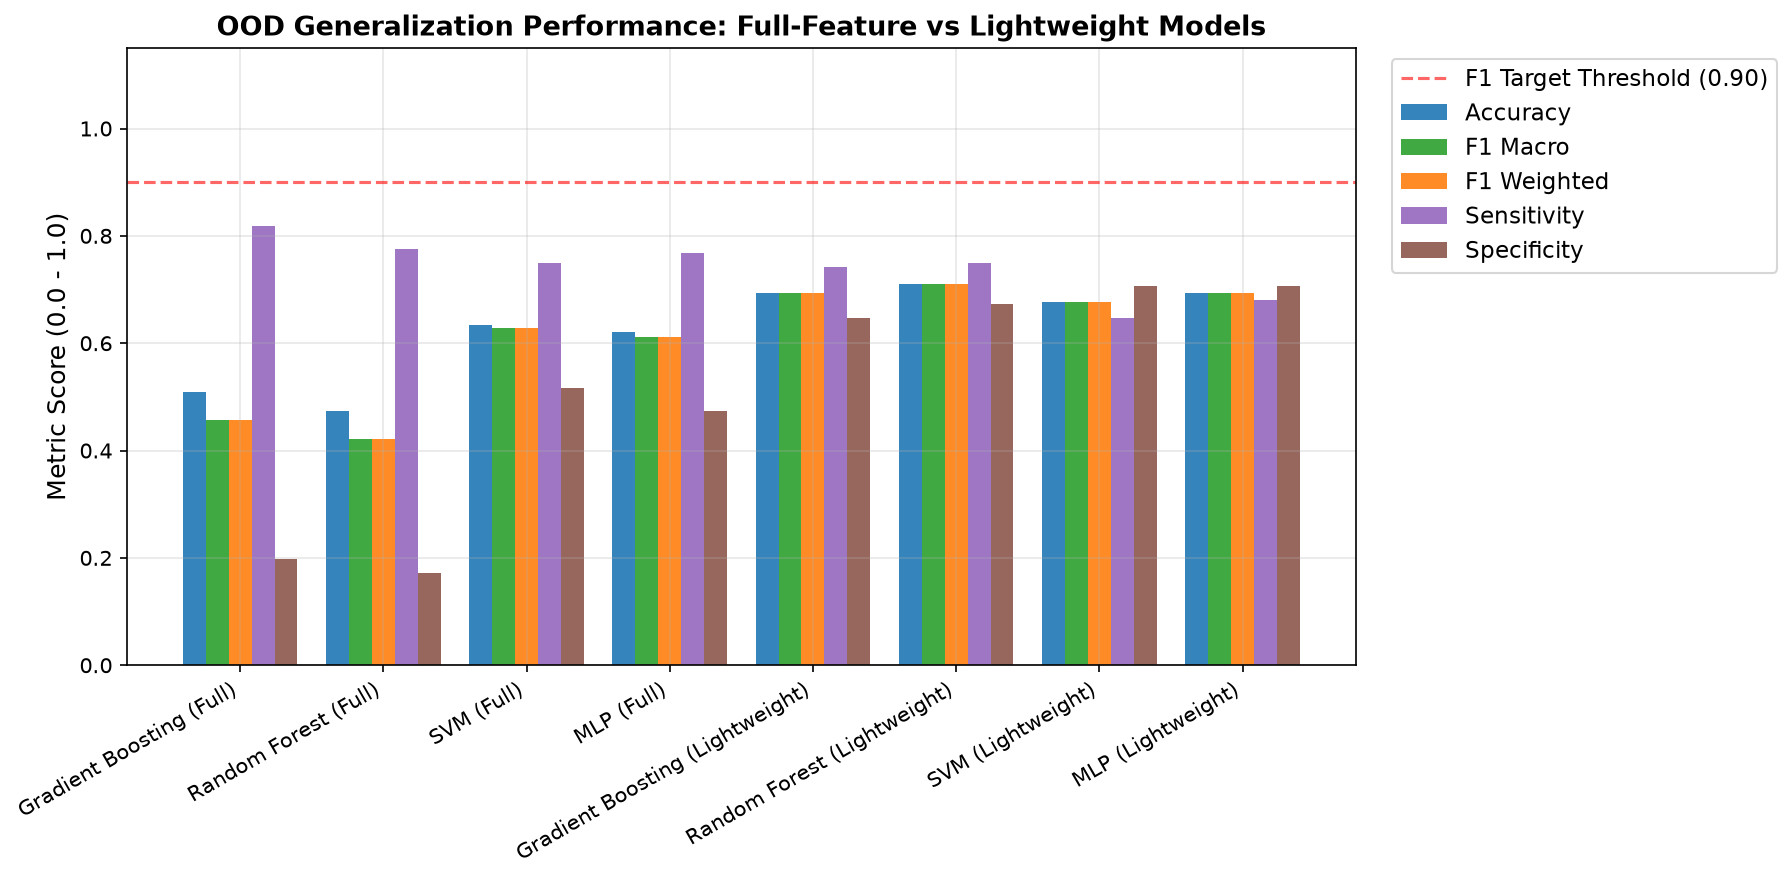

In [7]:
# Figure 1: Model Comparison (Full vs Light across Accuracy, Macro F1, Sensitivity, Specificity)
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = metrics_df.copy()
plot_data["display_name"] = plot_data["family"] + " (" + plot_data["type"] + ")"

metric_cols = ["accuracy", "f1_macro", "f1_weighted", "sensitivity", "specificity"]
x = np.arange(len(plot_data))
width = 0.16

colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]
for i, (col, color) in enumerate(zip(metric_cols, colors)):
    offset = (i - len(metric_cols) / 2 + 0.5) * width
    ax.bar(x + offset, plot_data[col], width, label=col.replace("_", " ").title(), color=color, alpha=0.9)

ax.set_ylabel("Metric Score (0.0 - 1.0)")
ax.set_title("OOD Generalization Performance: Full-Feature vs Lightweight Models", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(plot_data["display_name"], rotation=30, ha="right")
ax.set_ylim(0, 1.15)
ax.axhline(0.90, color="red", linestyle="--", alpha=0.6, label="F1 Target Threshold (0.90)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig1_path = OUTPUTS_DIR / "model_comparison_full_vs_light.png"
plt.savefig(fig1_path, dpi=200, bbox_inches="tight")
print(f"Saved Figure 1: {fig1_path}")
plt.show()


Saved Figure 2: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization/confusion_matrices_all_models.png


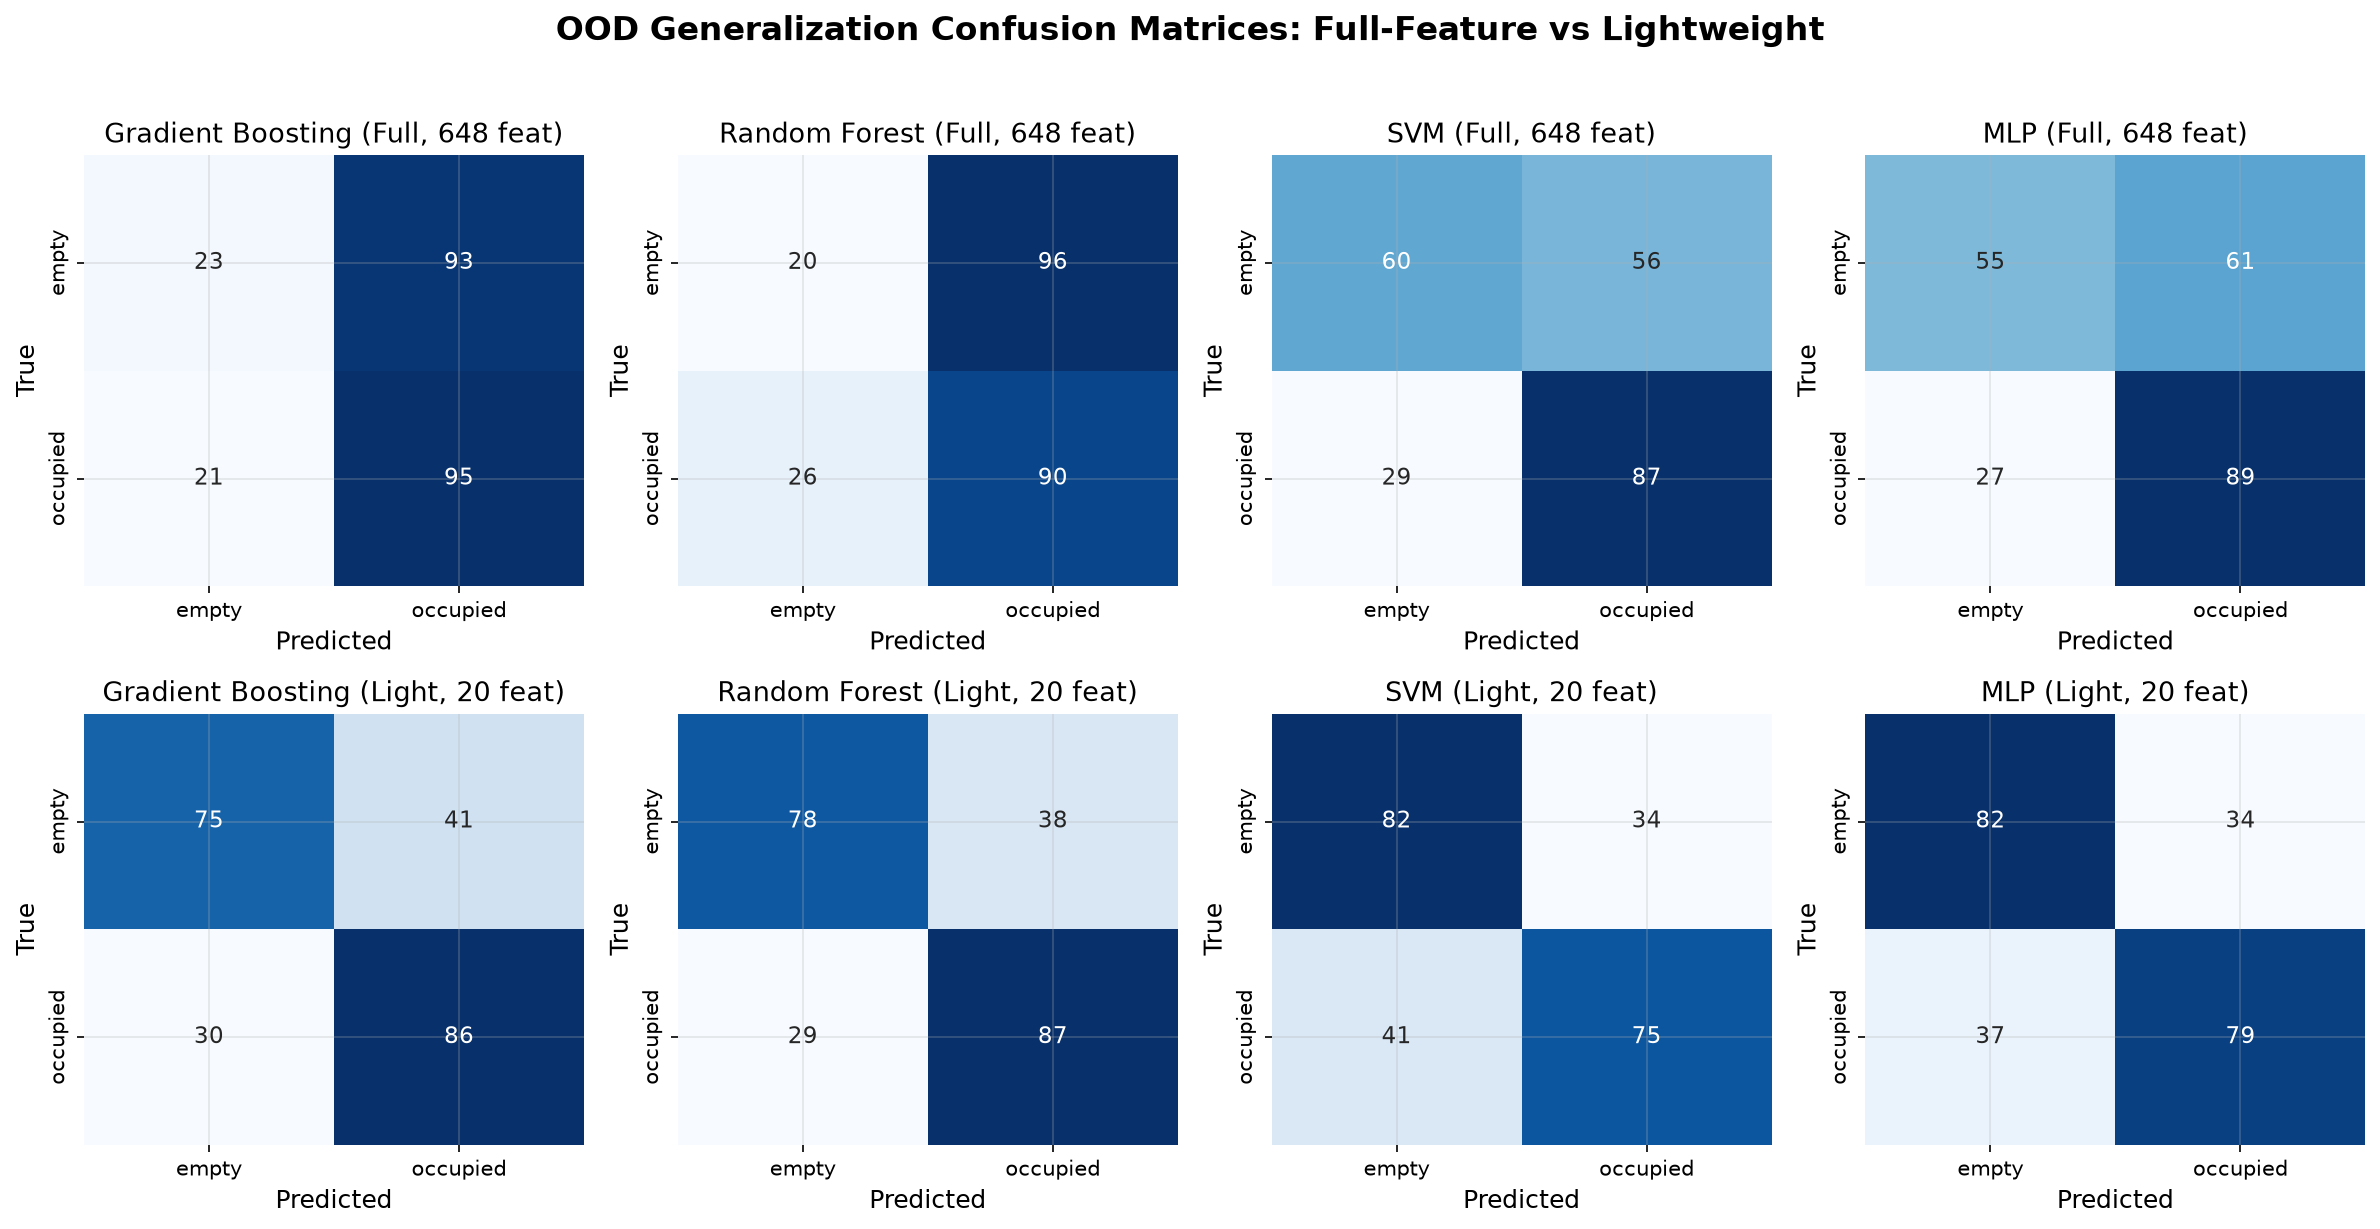

In [8]:
# Figure 2: Confusion Matrices Grid (2 Rows x 4 Columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
families = ["Gradient Boosting", "Random Forest", "SVM", "MLP"]

for col_idx, fam in enumerate(families):
    # Row 0: Full model
    full_name = metrics_df[(metrics_df["family"] == fam) & (metrics_df["type"] == "Full")]["model_name"].iloc[0]
    y_pred_full = predictions_dict[full_name]
    plot_confusion_matrix(y_true, y_pred_full, ax=axes[0, col_idx], title=f"{fam} (Full, 648 feat)")
    
    # Row 1: Light model
    light_name = metrics_df[(metrics_df["family"] == fam) & (metrics_df["type"] == "Lightweight")]["model_name"].iloc[0]
    y_pred_light = predictions_dict[light_name]
    plot_confusion_matrix(y_true, y_pred_light, ax=axes[1, col_idx], title=f"{fam} (Light, 20 feat)")

plt.suptitle("OOD Generalization Confusion Matrices: Full-Feature vs Lightweight", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

fig2_path = OUTPUTS_DIR / "confusion_matrices_all_models.png"
plt.savefig(fig2_path, dpi=200, bbox_inches="tight")
print(f"Saved Figure 2: {fig2_path}")
plt.show()


Saved Figure 3: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization/robustness_by_distance.png


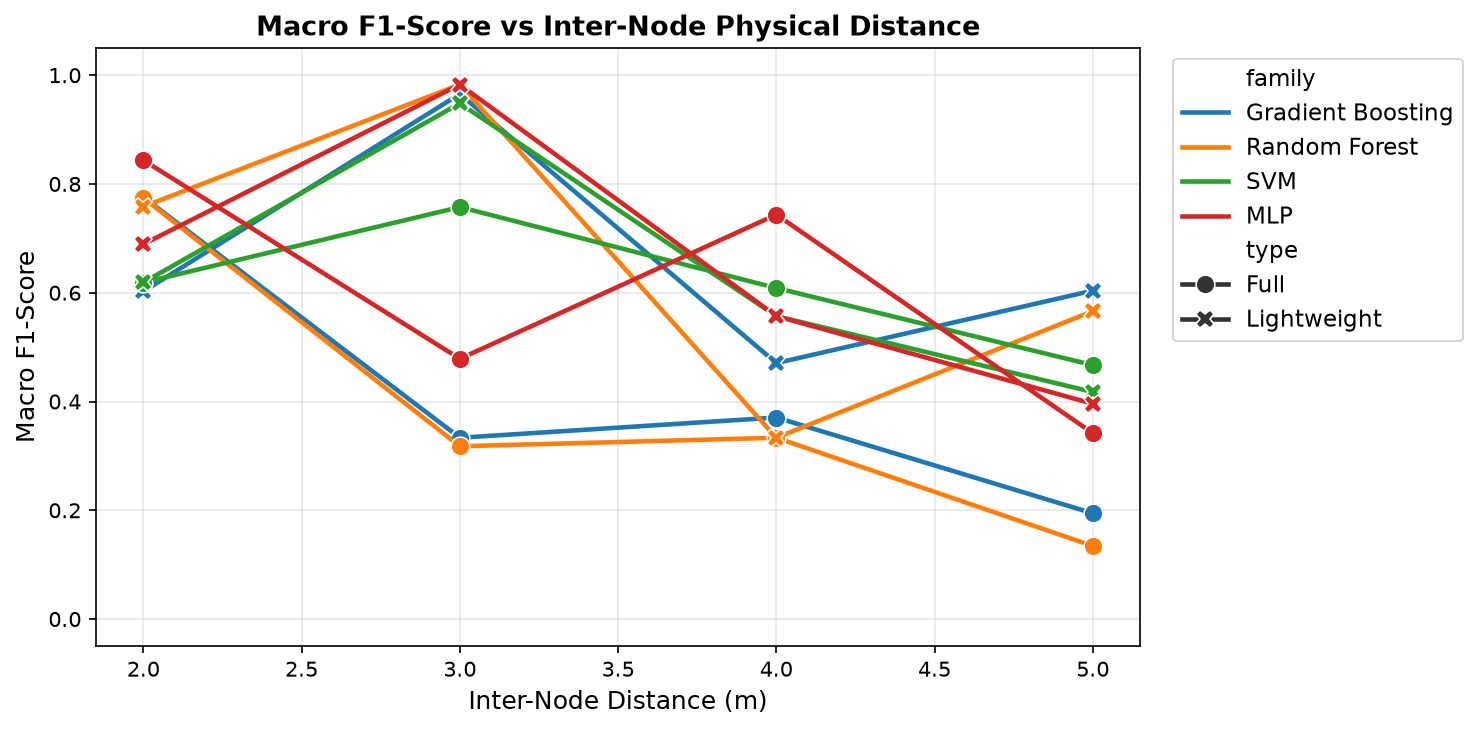

In [9]:
# Figure 3: Robustness across Inter-Node Distances
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=metrics_by_dist_df,
    x="distance_m",
    y="f1_macro",
    hue="family",
    style="type",
    markers=True,
    dashes=False,
    ax=ax,
    linewidth=2.2,
    markersize=9
)
ax.set_title("Macro F1-Score vs Inter-Node Physical Distance", fontweight="bold")
ax.set_xlabel("Inter-Node Distance (m)")
ax.set_ylabel("Macro F1-Score")
ax.set_ylim(-0.05, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig3_path = OUTPUTS_DIR / "robustness_by_distance.png"
plt.savefig(fig3_path, dpi=200, bbox_inches="tight")
print(f"Saved Figure 3: {fig3_path}")
plt.show()


Saved Figure 4: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization/robustness_by_environment.png


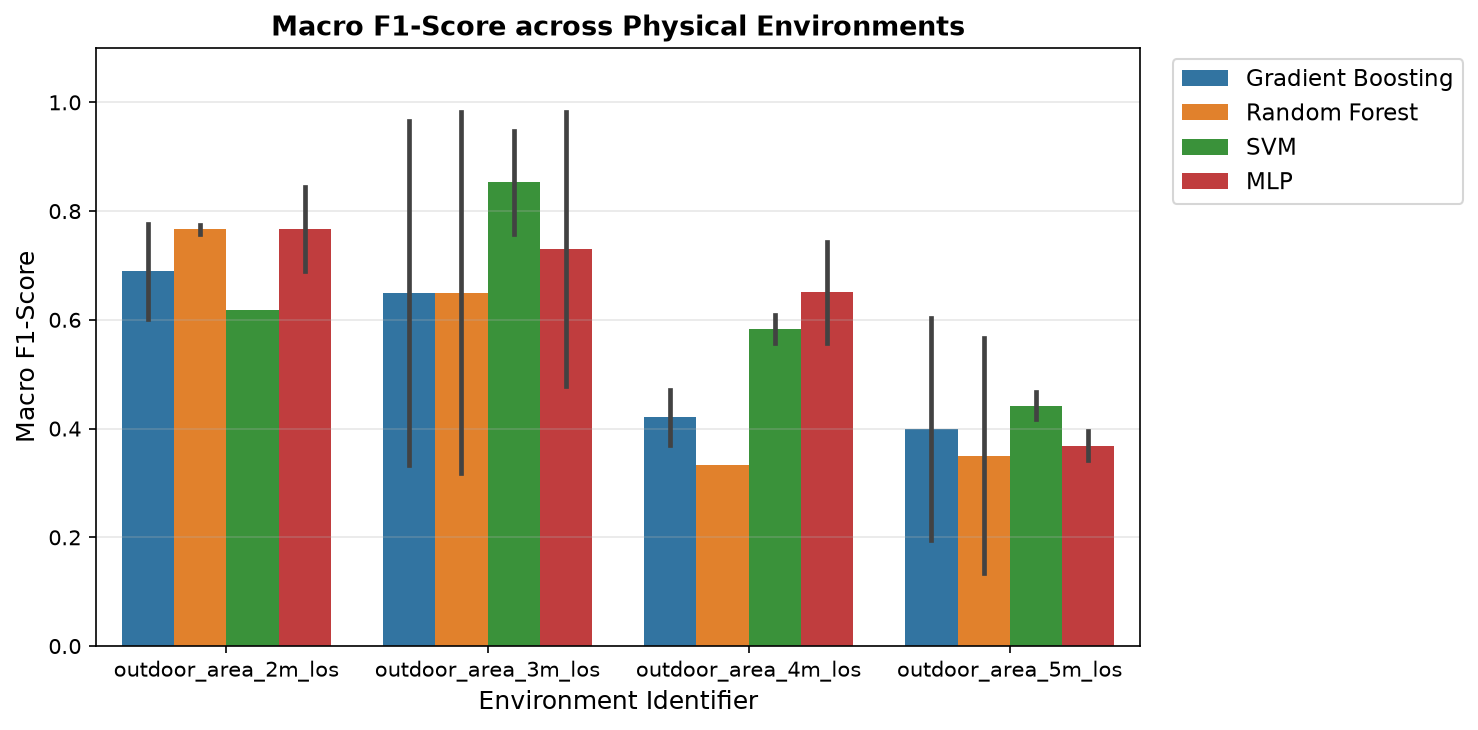

In [10]:
# Figure 4: Robustness across Physical Environments
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=metrics_by_env_df,
    x="environment_id",
    y="f1_macro",
    hue="family",
    ax=ax,
    palette="tab10"
)
ax.set_title("Macro F1-Score across Physical Environments", fontweight="bold")
ax.set_xlabel("Environment Identifier")
ax.set_ylabel("Macro F1-Score")
ax.set_ylim(0, 1.1)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

fig4_path = OUTPUTS_DIR / "robustness_by_environment.png"
plt.savefig(fig4_path, dpi=200, bbox_inches="tight")
print(f"Saved Figure 4: {fig4_path}")
plt.show()


## 8. Artifact Export & Summary Report Generation

Save all metrics, tables, and serialized reports to `outputs/generalization/`.

In [11]:
# 1. Save summary CSVs
summary_csv = OUTPUTS_DIR / "metrics_summary.csv"
metrics_df.to_csv(summary_csv, index=False)

dist_csv = OUTPUTS_DIR / "metrics_by_distance.csv"
metrics_by_dist_df.to_csv(dist_csv, index=False)

env_csv = OUTPUTS_DIR / "metrics_by_environment.csv"
metrics_by_env_df.to_csv(env_csv, index=False)

# 2. Save summary JSONs
summary_json = OUTPUTS_DIR / "metrics_summary.json"
metrics_df.to_json(summary_json, orient="records", indent=2)

# 3. Save comprehensive generalization report
report_data = {
    "campaign": "OOD Generalization Testing Appendix",
    "total_sessions": len(loaded_sessions),
    "total_windows": len(features_df),
    "environments": list(features_df["environment_id"].unique()),
    "distances_m": [float(d) for d in sorted(features_df["tx_rx_los_distance_m"].unique())],
    "models_evaluated": len(metrics_df),
    "metrics": metrics_df.to_dict(orient="records"),
    "generated_figures": [
        "model_comparison_full_vs_light.png",
        "confusion_matrices_all_models.png",
        "robustness_by_distance.png",
        "robustness_by_environment.png"
    ]
}

report_json = OUTPUTS_DIR / "generalization_report.json"
with open(report_json, "w", encoding="utf-8") as f:
    json.dump(report_data, f, indent=2)

print("=" * 65)
print("GENERALIZATION BENCHMARK COMPLETE")
print(f"Artifacts exported to: {OUTPUTS_DIR.resolve()}")
print(f"  - {summary_csv.name}")
print(f"  - {summary_json.name}")
print(f"  - {dist_csv.name}")
print(f"  - {env_csv.name}")
print(f"  - {report_json.name}")
print("=" * 65)


GENERALIZATION BENCHMARK COMPLETE
Artifacts exported to: /home/xavier/dev/wifi-csi-presence-detection/outputs/generalization
  - metrics_summary.csv
  - metrics_summary.json
  - metrics_by_distance.csv
  - metrics_by_environment.csv
  - generalization_report.json
